#FIR Filter Design via ANN

Based on: "FIR Filter Design Based Neural Network"
          Alwahab, Zaghar, Laki — ELTE Eotvos Lorand University

KEY FIX vs naive implementation:
  The paper does NOT train on a generic frequency-domain dataset.
  Instead, a SQUARE WAVE near the cutoff is used as input.
  The square wave has:

      ft = 0.5 * fc ± n * Δf  
  Its FUNDAMENTAL falls in the passband; its HARMONICS fall in the stopband.
  This lets a single signal probe ALL bands simultaneously.

  The ANN then learns to:
  
      - Pass   the fundamental  (passband)
      - Reject the harmonics    (stopband)
  using modified backprop with priority weights Pp / Ps.

Design flow :

  1. Rectangular window → initial weights
  2. Ideal filter TF → target
  3. Square wave generator → input signal
  4. FIR filter output (time domain)
  5. FFT of output → frequency domain
  6. Modified BP → update weights → repeat until convergence


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0d0d1a",
    "axes.facecolor":   "#13132b",
    "axes.edgecolor":   "#3a3a5c",
    "axes.labelcolor":  "#c8c8ee",
    "xtick.color":      "#9999bb",
    "ytick.color":      "#9999bb",
    "text.color":       "#eeeeff",
    "grid.color":       "#2a2a4a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#13132b",
    "legend.edgecolor": "#3a3a5c",
    "font.family":      "monospace",
})

# SECTION 1 — PARAMETERS

In [2]:
PARAMS = {
    "filter_type":           "lowpass",
    "order":                 25,
    "cutoff1":               0.2,
    "cutoff2":               0.6,
    "transition_width":      0.08,

    # ── ANN configurations ────────────────────────────────────────────────
    #  NN1=Pp=2,Ps=1 (passband priority → less pass ripple)
    #  NN2=Pp=1,Ps=2 (stopband priority → deeper stopband)
    #  NN3=Pp=1,Ps=1 (balanced)
    "nn_configs": {
        "NN1 (pass focus)": {"Pp": 2, "Ps": 1},
        "NN2 (stop focus)": {"Pp": 1, "Ps": 2},
        "NN3 (balanced)":   {"Pp": 1, "Ps": 1},
    },

    "delta_f":               0.02,
    "n_harmonics":           15,
    "signal_length":         512,
    "n_freq_pts":            1024,

    "learning_rate":         0.05,
    "momentum":              0.9,
    "max_iterations":        10000,
    "convergence_threshold": 0.0001,
    "n_random_runs":         5,
}


# SECTION 2 — SQUARE WAVE GENERATOR

In [3]:
def generate_square_wave(fc, delta_f, n_harmonics, signal_length):
    """

    ft = 0.5 * fc  (fundamental — sits in passband)
    Odd harmonics: 3ft, 5ft, … progressively fall into the stopband.
    ± n·Δf tones probe the transition band edges.

    Using ONE signal simultaneously tests ALL bands of the filter —
    this replaces a conventional dataset.
    """
    n   = np.arange(signal_length)
    ft  = 0.5 * fc

    # Fourier series of square wave: sum of odd harmonics
    x = np.zeros(signal_length)
    k = 1
    while k * ft <= 1.0:               # stop at Nyquist
        x += (1.0 / k) * np.sin(2 * np.pi * k * ft * n)
        k += 2                         # odd harmonics only

    # ± n·Δf tones to probe transition band (Eq. 2)
    for ni in range(1, n_harmonics + 1):
        for sign in (+1, -1):
            fi = ft + sign * ni * delta_f
            if 0 < fi < 1.0:
                x += 0.1 * np.sin(2 * np.pi * fi * n)

    return x / (np.max(np.abs(x)) + 1e-12)   # normalize to ±1


def build_ideal_H(n_freq_pts, fc, transition_width, filter_type="lowpass", fc2=0.6):
    """
    Build the ideal magnitude response H_ideal[k] on a uniform grid of
    n_freq_pts points from 0 to 1 (normalized, where 1 = Nyquist).

    Passband → 1.0,  Stopband → 0.0,  Transition → linear ramp.
    This is the TARGET the ANN is trained to approximate.
    """
    freqs   = np.linspace(0, 1, n_freq_pts)
    H_ideal = np.zeros(n_freq_pts)
    tw      = transition_width

    if filter_type == "lowpass":
        H_ideal[freqs <= fc - tw/2] = 1.0
        tr = (freqs > fc - tw/2) & (freqs < fc + tw/2)
        if tr.sum() > 1:
            H_ideal[tr] = np.linspace(1, 0, tr.sum())

    elif filter_type == "highpass":
        H_ideal[freqs >= fc + tw/2] = 1.0
        tr = (freqs > fc - tw/2) & (freqs < fc + tw/2)
        if tr.sum() > 1:
            H_ideal[tr] = np.linspace(0, 1, tr.sum())

    elif filter_type == "bandpass":
        mask = (freqs >= fc + tw/2) & (freqs <= fc2 - tw/2)
        H_ideal[mask] = 1.0
        tr1 = (freqs > fc - tw/2) & (freqs < fc + tw/2)
        tr2 = (freqs > fc2 - tw/2) & (freqs < fc2 + tw/2)
        if tr1.sum() > 1: H_ideal[tr1] = np.linspace(0, 1, tr1.sum())
        if tr2.sum() > 1: H_ideal[tr2] = np.linspace(1, 0, tr2.sum())

    elif filter_type == "bandstop":
        H_ideal[:] = 1.0
        mask = (freqs >= fc + tw/2) & (freqs <= fc2 - tw/2)
        H_ideal[mask] = 0.0
        tr1 = (freqs > fc - tw/2) & (freqs < fc + tw/2)
        tr2 = (freqs > fc2 - tw/2) & (freqs < fc2 + tw/2)
        if tr1.sum() > 1: H_ideal[tr1] = np.linspace(1, 0, tr1.sum())
        if tr2.sum() > 1: H_ideal[tr2] = np.linspace(0, 1, tr2.sum())

    return freqs, H_ideal


# SECTION 3 — BAND UTILITIES

In [4]:
def get_bands(params):
    """Return (pass_ranges, stop_ranges) list-of-tuples for each filter type."""
    fc1 = params["cutoff1"]
    fc2 = params["cutoff2"]
    tw  = params["transition_width"]
    ft  = params["filter_type"]

    if ft == "lowpass":
        return [(0.0, fc1 - tw/2)], [(fc1 + tw/2, 1.0)]
    elif ft == "highpass":
        return [(fc1 + tw/2, 1.0)], [(0.0, fc1 - tw/2)]
    elif ft == "bandpass":
        return ([(fc1 + tw/2, fc2 - tw/2)],
                [(0.0, fc1 - tw/2), (fc2 + tw/2, 1.0)])
    elif ft == "bandstop":
        return ([(0.0, fc1 - tw/2), (fc2 + tw/2, 1.0)],
                [(fc1 + tw/2, fc2 - tw/2)])
    raise ValueError(f"Unknown filter_type: {ft}")


def freq_band_masks(freqs, pass_ranges, stop_ranges):

    pb = np.zeros(len(freqs), dtype=bool)
    sb = np.zeros(len(freqs), dtype=bool)
    for lo, hi in pass_ranges:
        pb |= (freqs >= lo) & (freqs <= hi)
    for lo, hi in stop_ranges:
        sb |= (freqs >= lo) & (freqs <= hi)
    return pb, sb


def compute_ripple(h, pass_ranges, stop_ranges, n_pts=4096):
    """
    Pass ripple (dB) = 20*log10(max_pass / min_pass)  — peak-to-peak, lower = better
    Stop atten  (dB) = -20*log10(max_stop / max_pass) — relative to passband peak,
                                                          higher = better
    """
    w, H  = signal.freqz(h, worN=n_pts)
    fn    = w / np.pi          # normalized 0→1
    Hm    = np.abs(H)

    pb, sb = freq_band_masks(fn, pass_ranges, stop_ranges)

    if not pb.any():
        return np.nan, np.nan

    pb_max = Hm[pb].max()
    pb_min = Hm[pb].min()

    # ── Passband ripple (straightforward peak-to-peak) ───
    pr = 20 * np.log10(pb_max / (pb_min + 1e-12))

    # ── Stopband attenuation (relative to passband peak) ─
    if sb.any():
        sb_max = Hm[sb].max()
        sr = -20 * np.log10(sb_max / (pb_max + 1e-12) + 1e-12)
    else:
        sr = np.nan

    return pr, sr


# SECTION 4 — MODIFIED BACKPROPAGATION
#             using square wave as the actual input signal

In [5]:
# ═══════════════════════════════════════════════════════════════════
# SECTION 4 — MODIFIED BACKPROPAGATION
# Exact gradient:
#   H(k) = Σ_n  h[n] · e^{-jπkn/(K-1)}        (DFT at K points)
#   Loss  = Σ_k  w(k) · (|H(k)| − H_ideal(k))²
#   ∂L/∂h[n] = 2/K · Σ_k  w(k)·(|H(k)|−H_ideal(k))·Re[Φ*(k,n)·H(k)/|H(k)|]
#   Priority: w(k) = Pp (passband), Ps (stopband), 1 (transition)
# ═══════════════════════════════════════════════════════════════════

def compute_H_vandermonde(h, K):
    """
    Evaluate H(k) at K evenly spaced frequencies from 0 to π.
    Returns H (complex, shape K) and Φ (complex, shape K×N).
    """
    N   = len(h)
    k   = np.arange(K, dtype=np.float64)
    n   = np.arange(N, dtype=np.float64)
    Phi = np.exp(-1j * np.pi * np.outer(k, n) / (K - 1))   # (K, N)
    H   = Phi @ h                                            # (K,)
    return H, Phi


def modified_bp_step(h, velocity, H_ideal, pb_mask, sb_mask, K, Pp, Ps, lr, momentum=0.9):
    """
    One modified backprop step with MOMENTUM (paper Eq. 5 + momentum extension).

    momentum=0.9 helps escape shallow local minima and speeds convergence.
    This is the standard SGD+momentum update:
        velocity = momentum * velocity + lr * gradient
        h_new    = h - velocity

    Returns: h_new, velocity_new, delta (convergence criterion)
    """
    # Current frequency response
    H, Phi = compute_H_vandermonde(h, K)
    H_mag  = np.abs(H)                          # (K,)
    err    = H_mag - H_ideal                     # (K,)

    # Priority weights
    w = np.ones(K)
    w[pb_mask] = Pp
    w[sb_mask] = Ps
    we = w * err                                 # (K,) weighted error

    # Magnitude gradient: Re[conj(H_unit) * Phi]
    H_unit = np.where(H_mag > 1e-10, H / H_mag, 0.0 + 0j)
    dMag   = np.real(np.conj(H_unit[:, None]) * Phi)   # (K, N)
    grad   = (we @ dMag) * 2.0 / K                     # (N,)

    # Gradient clipping
    g_norm = np.linalg.norm(grad)
    if g_norm > 1.0:
        grad /= g_norm

    # Momentum update
    velocity_new = momentum * velocity + lr * grad
    h_new        = h - velocity_new
    delta        = np.sum(np.abs(h_new - h))
    return h_new, velocity_new, delta


def train_ann(h_init, params, Pp, Ps, label="ANN"):
    pass_ranges, stop_ranges = get_bands(params)
    K        = params["n_freq_pts"]
    lr       = params["learning_rate"]
    mu       = params.get("momentum", 0.9)
    maxIt    = params["max_iterations"]
    conv     = params["convergence_threshold"]

    freqs, H_ideal = build_ideal_H(
        K, params["cutoff1"], params["transition_width"],
        params["filter_type"], params["cutoff2"],
    )
    pb_mask, sb_mask = freq_band_masks(freqs, pass_ranges, stop_ranges)

    h        = h_init.copy()
    velocity = np.zeros_like(h)
    history  = []
    best_h   = h.copy()
    best_sr  = -999

    print(f"  [{label}]  Pp={Pp}, Ps={Ps}  training", end="", flush=True)

    lr_current = lr

    for it in range(maxIt):
        h, velocity, delta = modified_bp_step(
            h, velocity, H_ideal, pb_mask, sb_mask, K, Pp, Ps, lr_current, mu
        )
        history.append(delta)

        # Track best result
        pr_cur, sr_cur = compute_ripple(h, pass_ranges, stop_ranges)
        if sr_cur > best_sr:
            best_sr = sr_cur
            best_h  = h.copy()

        # Adaptive LR: reduce if stagnating
        if it > 100 and it % 500 == 0:
            recent = history[-100:]
            if max(recent) - min(recent) < 1e-5:
                lr_current *= 0.5
                velocity   *= 0.1
                print(f"(lr→{lr_current:.5f})", end="", flush=True)

        if it % 300 == 0:
            print(".", end="", flush=True)

        if delta < conv:
            print(f" converged @ iter {it+1}  (Δ={delta:.6f})")
            break
    else:
        print(f" max iter reached  (Δ={delta:.6f})")

    return best_h, history


# SECTION 5 — CLASSICAL METHODS

In [6]:
def design_classical(params):
    """Four classical FIR design methods for comparison."""
    N         = params["order"]
    ft        = params["filter_type"]
    fc1, fc2  = params["cutoff1"], params["cutoff2"]
    tw        = params["transition_width"]
    cutoffs   = fc1 if ft in ("lowpass", "highpass") else [fc1, fc2]
    pass_zero = ft in ("lowpass", "bandstop")

    beta = 1.5

    out = {}
    out["Rectangular"] = signal.firwin(N, cutoffs, window="boxcar",
                                       pass_zero=pass_zero)
    out["Kaiser"]      = signal.firwin(N, cutoffs, window=("kaiser", 1.5),
                                       pass_zero=pass_zero)

    # Band edges — fs=2.0 means normalized freq 1.0 = Nyquist
    if ft == "lowpass":
        bands_ls = [0.0, fc1 - tw/2,  fc1 + tw/2,  1.0]
        desired  = [1, 0]
        weights  = [1, 1]

    elif ft == "highpass":
        bands_ls = [0.0, fc1 - tw/2,  fc1 + tw/2,  1.0]
        desired  = [0, 1]
        weights  = [1, 1]

    elif ft == "bandpass":
        bands_ls = [0.0, fc1 - tw/2, fc1 + tw/2, fc2 - tw/2, fc2 + tw/2, 1.0]
        desired  = [0, 1, 0]
        weights  = [1, 1, 1]

    elif ft == "bandstop":
        bands_ls = [0.0, fc1 - tw/2, fc1 + tw/2, fc2 - tw/2, fc2 + tw/2, 1.0]
        desired  = [1, 0, 1]
        weights  = [1, 1, 1]

    # firls desired must be per edge (repeated per band)
    desired_firls = [v for d in desired for v in (d, d)]

    try:
        out["Firls"] = signal.firls(N, bands_ls, desired_firls)
        print("  Firls : OK")
    except Exception as e:
        print(f"  Firls FAILED: {e}")
        out["Firls"] = out["Kaiser"].copy()

    try:
        # fs=2.0 is the key fix — remez normalizes to fs/2
        out["Remez"] = signal.remez(N, bands_ls, desired, fs=2.0)
        print("  Remez : OK")
    except Exception as e:
        print(f"  Remez FAILED: {e}")
        out["Remez"] = out["Kaiser"].copy()

    return out

In [7]:
# ── Classical ANN: random initial weights ──────────────────────

def classical_ann_random(params):
    """
    Trains ANN with purely random initial weights (no window-method init).
    Runs multiple times to show instability.
    Returns: best_h, best_pr, best_sr, worst_sr, history_of_best_run
    """
    pass_ranges, stop_ranges = get_bands(params)
    N         = params["order"]
    n_runs    = params["n_random_runs"]

    best_h   = None
    best_sr  = -999
    worst_sr =  999
    best_hist = []

    print(f"  Running {n_runs} random-init trials...", end="", flush=True)

    for run in range(n_runs):
        h_rand = np.random.uniform(-0.5, 0.5, N)

        h_t, hist = train_ann(
            h_rand, params,
            Pp=1, Ps=1,
            label=f"rand-{run}"
        )
        pr_t, sr_t = compute_ripple(h_t, pass_ranges, stop_ranges)

        if sr_t > best_sr:
            best_sr   = sr_t
            best_h    = h_t.copy()
            best_hist = hist
            best_pr   = pr_t

        if sr_t < worst_sr:
            worst_sr = sr_t

    print(f"\n  Random init spread: best stop={best_sr:.1f} dB, worst stop={worst_sr:.1f} dB")
    print(f"  (Demonstrates instability)")

    return best_h, best_pr, best_sr, worst_sr, best_hist


# SECTION 6 — RUN EVERYTHING

In [8]:
def run_all(params):
    np.random.seed(0)
    pass_ranges, stop_ranges = get_bands(params)

    print("=" * 65)
    print("  FIR ANN — Modified Backprop + Square Wave (Paper-Accurate)")
    print("=" * 65)
    print(f"  Type : {params['filter_type'].upper()}  |  Order : {params['order']}")
    fc_str = f"{params['cutoff1']}"
    if params['filter_type'] in ('bandpass', 'bandstop'):
        fc_str += f"{params['cutoff2']}"
    print(f"  fc   : {fc_str}    transition : {params['transition_width']}")
    print(f"  Square wave  ft=0.5×fc={0.5*params['cutoff1']:.3f}  "
          f"Δf={params['delta_f']}  n={params['n_harmonics']}")
    print(f"  Freq pts : {params['n_freq_pts']}   "
          f"LR={params['learning_rate']}   maxIt={params['max_iterations']}")
    print("=" * 65)

    all_results = {}

    # ── [1] Classical methods ─────────────────────────────────────────────
    print("\n[1] Classical FIR design methods")
    for name, h in design_classical(params).items():
        pr, sr = compute_ripple(h, pass_ranges, stop_ranges)
        all_results[name] = {"h": h, "pr": pr, "sr": sr, "hist": None}
        print(f"  {name:<12}  pass={pr:.2f} dB  stop={sr:.1f} dB")

    # ── [2] Classical ANN: random init (shows instability) ───────────────
    print("\n[2] Classical ANN — random initial weights (paper §IV-A)")
    h_rb, pr_rb, sr_rb, worst_sb, hist_rb = classical_ann_random(params)
    all_results["ANN-random (best)"] = {
        "h": h_rb, "pr": pr_rb, "sr": sr_rb, "hist": hist_rb,
        "worst_sb": worst_sb,
    }

    # ── [3] Proposed: rectangular window init + modified BP ───────────────
    # g(j) = 0.1 · h_max · random(0,1]
    # w_j  = h_j + g(j)
    print("\n[3] Proposed — rectangular window init + modified BP ")
    N        = params["order"]
    fc1, fc2 = params["cutoff1"], params["cutoff2"]
    ft       = params["filter_type"]
    cutoffs  = fc1 if ft in ("lowpass", "highpass") else [fc1, fc2]
    pass_zero = ft in ("lowpass", "bandstop")

    h_rect = signal.firwin(N, cutoffs, window="boxcar", pass_zero=pass_zero)
    hmax   = np.max(np.abs(h_rect))
    g      = 0.1 * hmax * np.random.uniform(0, 1, N)
    h_init = h_rect + g

    for nn_name, cfg in params["nn_configs"].items():
        h_t, hist = train_ann(h_init.copy(), params,
                               Pp=cfg["Pp"], Ps=cfg["Ps"], label=nn_name)
        pr, sr = compute_ripple(h_t, pass_ranges, stop_ranges)
        all_results[nn_name] = {"h": h_t, "pr": pr, "sr": sr, "hist": hist}
        print(f"  {nn_name:<24}  pass={pr:.2f} dB  stop={sr:.1f} dB")

    return all_results, pass_ranges, stop_ranges


# SECTION 7 — PLOTS

In [9]:
COLORS = {
    "Rectangular":           "#ff6b6b",
    "Kaiser":                "#ffd166",
    "Firls":                 "#06d6a0",
    "Remez":                 "#4cc9f0",
    "ANN-random (best)":     "#f72585",
    "NN1 (pass focus)":      "#c77dff",
    "NN2 (stop focus)":      "#48cae4",
    "NN3 (balanced)":        "#80ffdb",
}
LS = {
    "Rectangular": (0,(3,1,1,1)), "Kaiser": "--", "Firls": "-.", "Remez": ":",
    "ANN-random (best)": (0,(5,2)),
    "NN1 (pass focus)": "-", "NN2 (stop focus)": "-", "NN3 (balanced)": "-",
}
LW = {k: (2.8 if "NN" in k or "ANN" in k else 1.5) for k in COLORS}


def plot_all(all_results, pass_ranges, stop_ranges, params):
    fc      = params["cutoff1"]
    n_fft_p = 2048

    # ── Generate square wave for display ─────────────────────────────────
    sq_wave = generate_square_wave(
        fc, params["delta_f"], params["n_harmonics"], params["signal_length"]
    )
    freqs_sq, H_ideal_display = build_ideal_H(
        params["n_freq_pts"], fc, params["transition_width"],
        params["filter_type"], params["cutoff2"]
    )

    fig = plt.figure(figsize=(22, 16))
    fig.suptitle(
        "FIR Filter: Classical vs ANN (Modified Backprop + Square Wave Input)\n"
        f"Type={params['filter_type'].upper()}  N={params['order']}  "
        f"fc={fc}"
        + (f"–{params['cutoff2']}" if params['filter_type'] in ('bandpass','bandstop') else ""),
        fontsize=13, y=0.99, color="#eeeeff"
    )

    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)
    ax_sq   = fig.add_subplot(gs[0, 0])
    ax_sqf  = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[0, 2])
    ax_freq = fig.add_subplot(gs[1, :2])
    ax_stop = fig.add_subplot(gs[1, 2])
    ax_conv = fig.add_subplot(gs[2, :2])
    ax_tab  = fig.add_subplot(gs[2, 2])

    # (a) Square wave — time domain
    ax_sq.set_title("(a) Square Wave Input\n(replaces dataset)", fontsize=9)
    ax_sq.plot(sq_wave[:128], color="#00d4ff", lw=1.2)
    ax_sq.set_xlabel("Sample n"); ax_sq.set_ylabel("Amplitude"); ax_sq.grid(True)
    ax_sq.text(0.03, 0.95,
               f"ft = 0.5×fc = {0.5*fc:.3f}\n"
               f"Fundamental → passband\nHarmonics   → stopband",
               transform=ax_sq.transAxes, fontsize=7.5, va="top", color="#aaffcc",
               bbox=dict(boxstyle="round", facecolor="#1a1a3a", alpha=0.7))

    # (b) Square wave — spectrum + ideal response overlay
    ax_sqf.set_title("(b) Square Wave Spectrum + Ideal H(k)", fontsize=9)
    Xsq   = np.abs(np.fft.rfft(sq_wave, n=params["n_freq_pts"]))
    f_sq  = np.linspace(0, 1, len(Xsq))
    ax_sqf.stem(f_sq, Xsq / (Xsq.max() + 1e-12),
                linefmt="#00d4ff", markerfmt=".", basefmt=" ", label="Square wave |X(f)|")
    ax_sqf.plot(freqs_sq, H_ideal_display, color="#ffff00", lw=2, ls="--", label="H_ideal")
    for lo, hi in pass_ranges:
        ax_sqf.axvspan(lo, hi, alpha=0.12, color="#00ff88")
    for lo, hi in stop_ranges:
        ax_sqf.axvspan(lo, hi, alpha=0.12, color="#ff4444")
    ft_fund = 0.5 * fc
    ax_sqf.axvline(ft_fund, color="#ffff00", ls=":", lw=1.2)
    ax_sqf.text(ft_fund + 0.01, 0.88, f"ft={ft_fund:.2f}\n(fund.)", fontsize=6.5, color="#ffff00")
    if 3*ft_fund < 1.0:
        ax_sqf.axvline(3*ft_fund, color="#ff9900", ls=":", lw=1.2)
        ax_sqf.text(3*ft_fund + 0.01, 0.55, f"3ft\n(harm.)", fontsize=6.5, color="#ff9900")
    ax_sqf.set_xlim(0, 1); ax_sqf.set_xlabel("Norm. Freq."); ax_sqf.set_ylabel("Magnitude")
    ax_sqf.legend(fontsize=7); ax_sqf.grid(True)

    # (c) Stopband attenuation bar chart
    names_b = list(all_results.keys())
    sbs_b   = [all_results[n]["sr"] for n in names_b]
    cols_b  = [COLORS.get(n, "#888888") for n in names_b]
    ax_bar.set_title("(c) Stopband Attenuation (dB)\n(higher = better)", fontsize=9)
    bars = ax_bar.barh(names_b, sbs_b, color=cols_b, alpha=0.85, height=0.6)
    for bar, val in zip(bars, sbs_b):
        ax_bar.text(max(val, 0) + 0.3, bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}", va="center", fontsize=7, color="white")
    ax_bar.set_xlabel("dB"); ax_bar.tick_params(axis="y", labelsize=7); ax_bar.grid(True, axis="x")

    # (d) Full frequency response
    ax_freq.set_title("(d) Frequency Response — All Methods", fontsize=9)
    for name, res in all_results.items():
        w, H = signal.freqz(res["h"], worN=n_fft_p)
        Hdb  = 20 * np.log10(np.abs(H) + 1e-12)
        ax_freq.plot(w/np.pi, Hdb,
                     color=COLORS.get(name, "white"),
                     ls=LS.get(name, "-"), lw=LW.get(name, 1.5),
                     label=name, alpha=0.9)
    for lo, hi in pass_ranges:
        ax_freq.axvspan(lo, hi, alpha=0.07, color="#00ff88")
    for lo, hi in stop_ranges:
        ax_freq.axvspan(lo, hi, alpha=0.07, color="#ff4444")
    ax_freq.set_ylim(-130, 10); ax_freq.set_xlim(0, 1)
    ax_freq.set_xlabel("Normalized Frequency (×π rad/sample)")
    ax_freq.set_ylabel("Magnitude (dB)")
    ax_freq.legend(fontsize=7.5, loc="lower left", ncol=2); ax_freq.grid(True)

    # (e) Stopband zoom
    sb_lo, sb_hi = stop_ranges[0]
    ax_stop.set_title("(e) Stopband Zoom", fontsize=9)
    for name, res in all_results.items():
        w, H = signal.freqz(res["h"], worN=n_fft_p)
        fn = w/np.pi
        mask = (fn >= sb_lo) & (fn <= min(sb_hi, 1.0))
        if mask.any():
            Hdb = 20 * np.log10(np.abs(H[mask]) + 1e-12)
            ax_stop.plot(fn[mask], Hdb,
                         color=COLORS.get(name, "white"),
                         ls=LS.get(name, "-"), lw=LW.get(name, 1.5),
                         label=name, alpha=0.9)
    ax_stop.set_ylim(-130, -10); ax_stop.set_xlabel("Norm. Freq.")
    ax_stop.set_ylabel("Magnitude (dB)"); ax_stop.legend(fontsize=6.5); ax_stop.grid(True)

    # (f) Convergence curves (ANN methods only)
    ax_conv.set_title("(f) ANN Convergence  Σ|Δh| per Iteration", fontsize=9)
    has_hist = False
    for name, res in all_results.items():
        if res["hist"] is not None:
            ax_conv.semilogy(res["hist"],
                             color=COLORS.get(name, "white"), lw=2,
                             label=name, alpha=0.9)
            has_hist = True
    if has_hist:
        ax_conv.axhline(params["convergence_threshold"],
                        color="#ffff44", ls="--", lw=1.2,
                        label=f"Threshold ({params['convergence_threshold']})")
        ax_conv.set_xlabel("Iteration"); ax_conv.set_ylabel("Σ|Δh|")
        ax_conv.legend(fontsize=7.5); ax_conv.grid(True)

    # (g) Summary table
    ax_tab.axis("off")
    ax_tab.set_title("(g) Summary", fontsize=9)
    rows = [[n, f"{v['pr']:.2f}", f"{v['sr']:.1f}"]
            for n, v in all_results.items()]
    tbl = ax_tab.table(cellText=rows,
                       colLabels=["Method", "Pass ripple (dB)", "Stop atten (dB)"],
                       loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1.05, 1.55)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor("#13132b" if r > 0 else "#2a2a55")
        cell.set_edgecolor("#3a3a5c")
        cell.set_text_props(color="#eeeeff")
        if r > 0 and "NN" in rows[r-1][0]:
            cell.set_facecolor("#1a1a44")

    plt.savefig("FIR_ANN_Results.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("[✓] Saved: FIR_ANN_Results.png")


# SECTION 8 — ENTRY POINT

  FIR ANN — Modified Backprop + Square Wave (Paper-Accurate)
  Type : LOWPASS  |  Order : 25
  fc   : 0.2    transition : 0.08
  Square wave  ft=0.5×fc=0.100  Δf=0.02  n=15
  Freq pts : 1024   LR=0.05   maxIt=10000

[1] Classical FIR design methods
  Firls : OK
  Remez : OK
  Rectangular   pass=1.11 dB  stop=19.8 dB
  Kaiser        pass=1.44 dB  stop=18.7 dB
  Firls         pass=1.30 dB  stop=16.6 dB
  Remez         pass=1.16 dB  stop=24.1 dB

[2] Classical ANN — random initial weights (paper §IV-A)
  Running 5 random-init trials...  [rand-0]  Pp=1, Ps=1  training. converged @ iter 288  (Δ=0.000099)
  [rand-1]  Pp=1, Ps=1  training. converged @ iter 215  (Δ=0.000098)
  [rand-2]  Pp=1, Ps=1  training.. converged @ iter 553  (Δ=0.000100)
  [rand-3]  Pp=1, Ps=1  training.. converged @ iter 422  (Δ=0.000099)
  [rand-4]  Pp=1, Ps=1  training.. converged @ iter 466  (Δ=0.000099)

  Random init spread: best stop=26.4 dB, worst stop=22.4 dB
  (Demonstrates instability)

[3] Proposed — rectangu

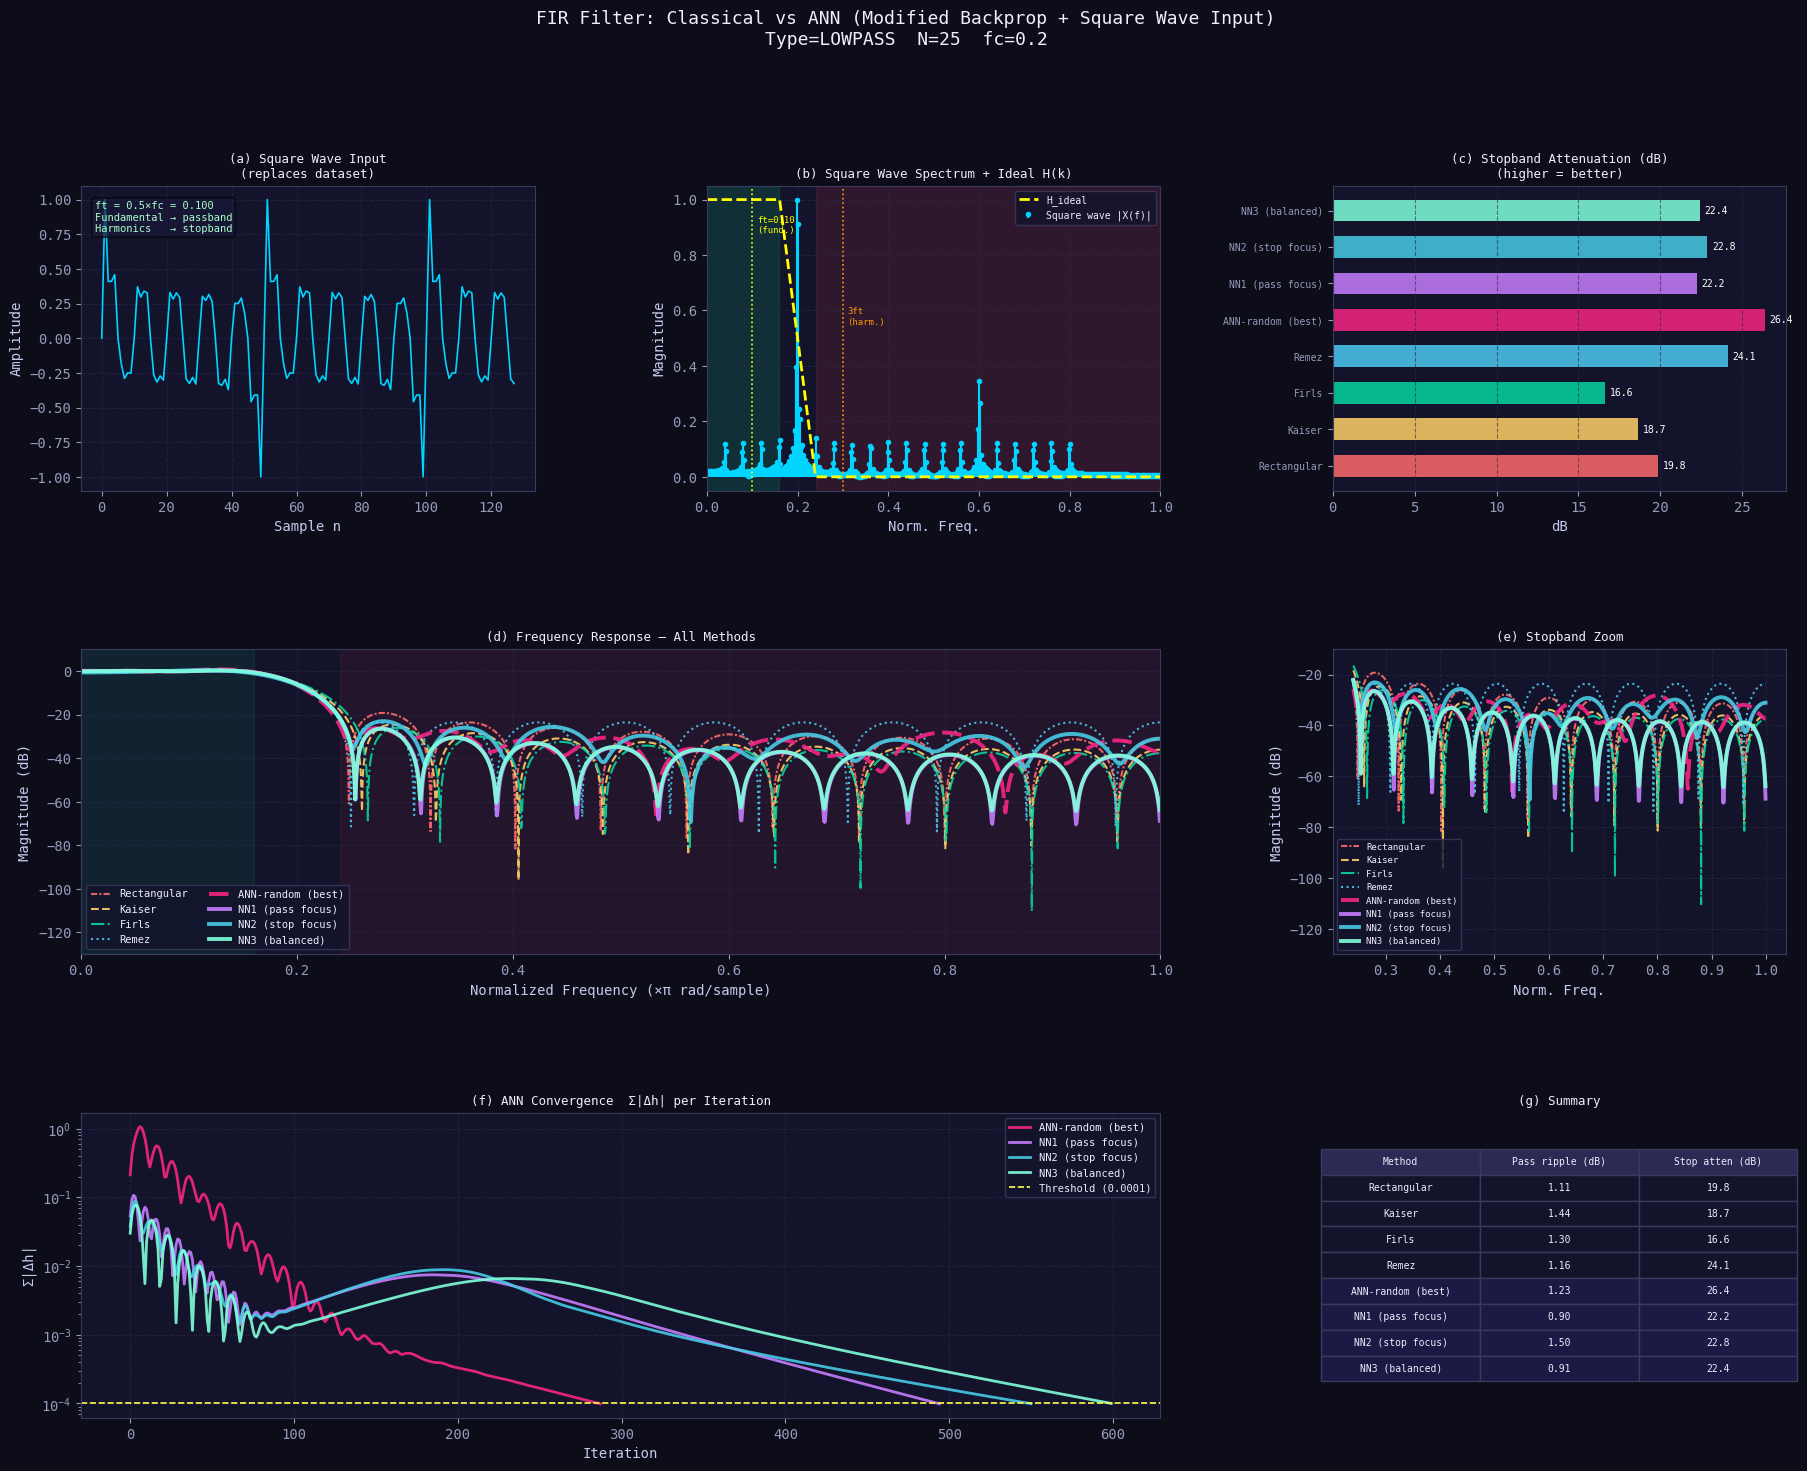

[✓] Saved: FIR_ANN_Fixed.png

  Method                         Pass ripple    Stop atten
  Rectangular                         1.11 dB        19.8 dB  
  Kaiser                              1.44 dB        18.7 dB  
  Firls                               1.30 dB        16.6 dB  
  Remez                               1.16 dB        24.1 dB  
  ANN-random (best)                   1.23 dB        26.4 dB   ◄ random init
  NN1 (pass focus)                    0.90 dB        22.2 dB   ◄ proposed ANN
  NN2 (stop focus)                    1.50 dB        22.8 dB   ◄ proposed ANN
  NN3 (balanced)                      0.91 dB        22.4 dB   ◄ proposed ANN


In [10]:
# ── Run everything ───────────────────────────────────────────────────────────
all_results, pass_ranges, stop_ranges = run_all(PARAMS)

# ── Plot ──────────────────────────────────────────────────────────────────────
plot_all(all_results, pass_ranges, stop_ranges, PARAMS)

# ── Final comparison table ────────────────────────────────────────────────────
print("\n" + "=" * 68)
print(f"  {'Method':<28} {'Pass ripple':>13} {'Stop atten':>13}")
print("=" * 68)
for n, v in all_results.items():
    tag = " ◄ proposed ANN" if "NN" in n and "random" not in n else (
          " ◄ random init"  if "random" in n else "")
    print(f"  {n:<28} {v['pr']:>11.2f} dB {v['sr']:>11.1f} dB  {tag}")
print("=" * 68)



#Section 9 - EXTRACT & EXPORT FILTER WEIGHTS

In [11]:
import numpy as np

print("="*60)
print("  FILTER WEIGHTS (FIR COEFFICIENTS / TAPS)")
print("="*60)

for name, res in all_results.items():
    h = res["h"]
    print(f"\n[{name}]  ({len(h)} taps)")
    print(np.array2string(h, precision=8, separator=", ",
                         floatmode="fixed", max_line_width=80))

# ── Save all weights to a .npz file ─────────────────────
save_dict = {name.replace(" ", "_").replace("(","").replace(")",""): res["h"]
             for name, res in all_results.items()}
np.savez("FIR_filter_weights.npz", **save_dict)
print(f"\n[✓] Weights saved to: FIR_filter_weights.npz")

# ── Also save as plain .csv (one row per method) ────────
import csv
with open("FIR_filter_weights.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["method"] + [f"h[{i}]" for i in range(PARAMS["order"])])
    for name, res in all_results.items():
        writer.writerow([name] + list(res["h"]))
print("[✓] Weights saved to: FIR_filter_weights.csv")

# ── Quick reload verification ────────────────────────────
loaded = np.load("FIR_filter_weights.npz")
print(f"\nVerification — keys in .npz: {list(loaded.keys())}")
print(f"NN3 weights checksum: {np.sum(loaded[list(loaded.keys())[-1]]):.6f}")

  FILTER WEIGHTS (FIR COEFFICIENTS / TAPS)

[Rectangular]  (25 taps)
[ 2.54657055e-02,  1.71694598e-02, -7.86994106e-18, -2.09848954e-02,
 -3.81985582e-02, -4.36554951e-02, -3.14773431e-02,  7.86994106e-18,
  4.72160146e-02,  1.01862822e-01,  1.52794233e-01,  1.88864058e-01,
  2.01887998e-01,  1.88864058e-01,  1.52794233e-01,  1.01862822e-01,
  4.72160146e-02,  7.86994106e-18, -3.14773431e-02, -4.36554951e-02,
 -3.81985582e-02, -2.09848954e-02, -7.86994106e-18,  1.71694598e-02,
  2.54657055e-02]

[Kaiser]  (25 taps)
[ 1.55129559e-02,  1.14201335e-02, -5.65421721e-18, -1.61282100e-02,
 -3.11293493e-02, -3.74165677e-02, -2.81588031e-02,  7.29541066e-18,
  4.50446202e-02,  9.93497695e-02,  1.51376510e-01,  1.88868468e-01,
  2.02520947e-01,  1.88868468e-01,  1.51376510e-01,  9.93497695e-02,
  4.50446202e-02,  7.29541066e-18, -2.81588031e-02, -3.74165677e-02,
 -3.11293493e-02, -1.61282100e-02, -5.65421721e-18,  1.14201335e-02,
  1.55129559e-02]

[Firls]  (25 taps)
[ 0.01374200,  0.01155808,

#Section 10 - Quantization of Weights

In [12]:
import numpy as np

h = all_results["NN3 (balanced)"]["h"]

TDC_BITS    = 4          # your TDC output
OUTPUT_BITS = 12         # bits going to DCO (change to 10 if DCO is coarse)
COEFF_BITS  = 12         # internal coefficient precision (Q1.15)

SCALE = 2**(COEFF_BITS - 1) - 1   # 32767

# Quantize coefficients
h_fixed = np.round(h * SCALE).astype(np.int32)

# Compute output bit growth
# When you convolve 4-bit input with 16-bit coefficients across N taps:
# Max accumulator value = sum(|h_fixed|) * 2**(TDC_BITS-1)
max_accum = int(np.sum(np.abs(h_fixed))) * (2**(TDC_BITS - 1))
accum_bits = int(np.ceil(np.log2(max_accum + 1))) + 1  # +1 for sign
print(f"Accumulator needs: {accum_bits} bits")
print(f"Right-shift to get {OUTPUT_BITS}-bit output: >> {accum_bits - OUTPUT_BITS}")

SHIFT = max(0, accum_bits - OUTPUT_BITS)

print(f"\nCoefficients (Q1.12, {COEFF_BITS}-bit):")
print(h_fixed)
print(f"\nVerilog shift: >> {SHIFT}")
print(f"Output to DCO: {OUTPUT_BITS} bits")

# Save
np.savetxt("adpll_loop_filter_coeffs.txt", h_fixed, fmt="%d", header=f"Q1.15 coefficients, shift>>{SHIFT} for {OUTPUT_BITS}-bit DCO output")

Accumulator needs: 16 bits
Right-shift to get 12-bit output: >> 4

Coefficients (Q1.12, 12-bit):
[ -41  -80 -115 -131 -113  -56   37  153  267  355  398  386  326  233
  131   44  -11  -30  -18   13   45   67   71   59   37]

Verilog shift: >> 4
Output to DCO: 12 bits


#Section 11 - Test Sequence

In [14]:
# Produces input.data (512 lines, each a 4-bit binary string to match TDC)
BITS  = 4                         # Matches your 4-bit TDC output
SCALE = 2**(BITS - 1) - 1        # 7 (for 4-bit signed: -8 to +7)

fc = PARAMS["cutoff1"]

sq_wave = generate_square_wave(
    fc, PARAMS["delta_f"], PARAMS["n_harmonics"], PARAMS["signal_length"]
)

list1 = []
for number in sq_wave:
    # Map normalized square wave (-1 to 1) to 4-bit signed range
    val     = int(round(number * SCALE))
    val     = max(-(2**(BITS-1)), min(2**(BITS-1)-1, val))  # clamp to [-8, 7]
    bin_str = np.binary_repr(val, BITS)                      # width = 4
    list1.append(bin_str)

with open('input.txt', 'w') as file:
    for b in list1:
        file.write(b + '\n')